In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import jaxdem as jd
import os
import matplotlib.pyplot as plt

In [2]:
silbert_phi = np.array([[0.00010250680283341849, 0.6384415584415581],
[0.0010250680283341838, 0.6381818181818179],
[0.004877216596885476, 0.636363636363636],
[0.01050764462712929, 0.6348051948051945],
[0.04877216596885476, 0.6233766233766231],
[0.09755450100468763, 0.6140259740259738],
[0.24383540982688315, 0.596103896103896],
[0.49994788007281477, 0.5742857142857143],
[1.000000000000002, 0.5581818181818182],
[9.755450100468742, 0.5446753246753248],])

silbert_zc = np.array([[0.00010507644627129323, 5.929133858267716],
[0.001025068028334185, 5.937007874015747],
[0.004877216596885476, 5.8267716535433065],
[0.010000000000000021, 5.771653543307086],
[0.04877216596885476, 5.385826771653543],
[0.1000000000000002, 5.173228346456693],
[0.24383540982688315, 4.5984251968503935],
[0.4757944314009414, 4.2204724409448815],
[0.9755450100468763, 3.992125984251968],
[9.516880666273561, 3.8818897637795273],])

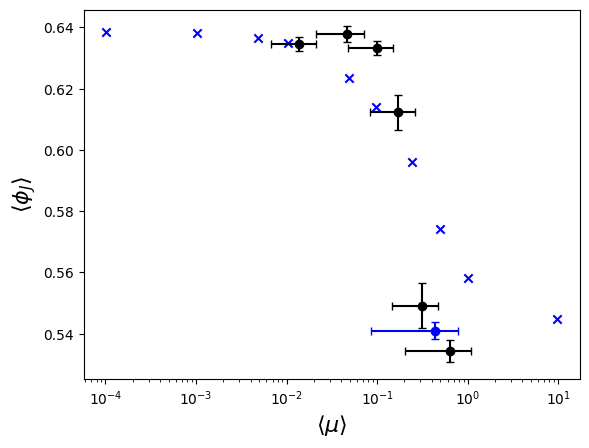

In [14]:
p_rad = 0.5


phi_data = np.load('data/phi_large.npz')
mu_data = np.load('data/mu_clump_large.npz')
for arad in np.unique(phi_data['arad']):
    phi_mask = phi_data['arad'] == arad
    mu_mask = mu_data['arad'] == arad
    mu_vals = mu_data['val'][mu_mask]
    phi_vals = phi_data['val'][phi_mask]
    plt.errorbar(
        np.mean(mu_vals), np.mean(phi_vals),
        xerr=np.std(mu_vals),
        yerr=np.std(phi_vals),
        fmt='ok',
        capsize=3,
    )


phi_data = np.load('data/phi_large_with_core.npz')
mu_data = np.load('data/mu_clump_large_with_core.npz')
for arad in np.unique(phi_data['arad']):
    phi_mask = phi_data['arad'] == arad
    mu_mask = mu_data['arad'] == arad
    mu_vals = mu_data['val'][mu_mask]
    phi_vals = phi_data['val'][phi_mask]
    plt.errorbar(
        np.mean(mu_vals), np.mean(phi_vals),
        xerr=np.std(mu_vals),
        yerr=np.std(phi_vals),
        fmt='ob',
        capsize=3,
    )

plt.scatter(silbert_phi[:, 0], silbert_phi[:, 1], c='b', marker='x')

plt.xscale('log')
plt.xlabel(r'$\langle \mu \rangle$', fontsize=16)
plt.ylabel(r'$\langle \phi_J \rangle$', fontsize=16)
plt.savefig('figures/jamming/phi_j.png', dpi=600)
plt.show()


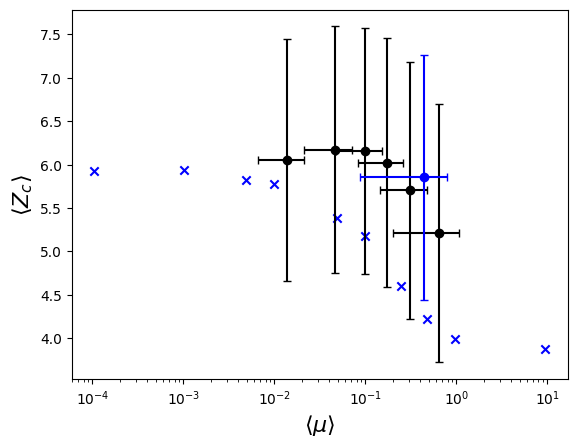

In [16]:
p_rad = 0.5


phi_data = np.load('data/phi_large.npz')
z_data = np.load('data/z_clump_large.npz')
mu_data = np.load('data/mu_clump_large.npz')
for arad in np.unique(phi_data['arad']):
    z_mask = z_data['arad'] == arad
    mu_mask = mu_data['arad'] == arad
    mu_vals = mu_data['val'][mu_mask]
    z_vals = z_data['val'][z_mask]
    plt.errorbar(
        np.mean(mu_vals), np.mean(z_vals),
        xerr=np.std(mu_vals),
        yerr=np.std(z_vals),
        fmt='ok',
        capsize=3,
    )

phi_data = np.load('data/phi_large_with_core.npz')
z_data = np.load('data/z_clump_large_with_core.npz')
mu_data = np.load('data/mu_clump_large_with_core.npz')
for arad in np.unique(phi_data['arad']):
    z_mask = z_data['arad'] == arad
    mu_mask = mu_data['arad'] == arad
    mu_vals = mu_data['val'][mu_mask]
    z_vals = z_data['val'][z_mask]
    plt.errorbar(
        np.mean(mu_vals), np.mean(z_vals),
        xerr=np.std(mu_vals),
        yerr=np.std(z_vals),
        fmt='ob',
        capsize=3,
    )

plt.scatter(silbert_zc[:, 0], silbert_zc[:, 1], c='b', marker='x')

plt.xscale('log')
plt.xlabel(r'$\langle \mu \rangle$', fontsize=16)
plt.ylabel(r'$\langle Z_c \rangle$', fontsize=16)
plt.savefig('figures/jamming/z_c.png', dpi=600)
plt.show()


In [ ]:
root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/server-data/test-jamming/asperity_radius-0.25-nv-43/large/0'

state = jd.utils.h5.load(os.path.join(root, 'state.h5'))
system = jd.utils.h5.load(os.path.join(root, 'system.h5'))

K = jnp.max(state.clump_ID) + 1
nl = system.collider.neighbor_list
cnl = state.clump_ID[nl]  # neighbor list of clump IDs
cnl += (-(cnl + 1) * (nl == -1))  # keep the -1 dummy indices

pos_p_global = state.q.rotate(state.q, state.pos_p)
pos = state.pos_c + pos_p_global

def per_particle_force(i, pos_pi, neighbors):
    def per_neighbor_force(j_id):
        valid = j_id != -1
        safe_j = jnp.maximum(j_id, 0)
        f, t = system.force_model.force(i, safe_j, pos, state, system)
        return f * valid, t * valid
    forces, _ = jax.vmap(per_neighbor_force)(neighbors)
    return forces

def per_particle_distance(i, pos_ci, neighbors):
    def per_neighbor_dist(j_id):
        valid = j_id != -1
        safe_j = jnp.maximum(j_id, 0)
        r = system.domain.displacement(pos_ci, state.pos_c[safe_j], system)
        return r * valid
    r = jax.vmap(per_neighbor_dist)(neighbors)
    return r

iota = jax.lax.iota(dtype=int, size=state.N)
forces_nl = jax.vmap(per_particle_force)(iota, pos_p_global, nl)
dists_nl = jax.vmap(per_particle_distance)(iota, state.pos_c, nl)

dist_norm = jnp.linalg.norm(dists_nl, axis=-1)
valid_mask = dist_norm > 0
dirs_nl = (dists_nl / (dist_norm + ~valid_mask * 1e-16)[..., None]) * valid_mask[..., None]

force_norm_mag = jnp.sum(forces_nl * dirs_nl, axis=-1)  # f dot r
force_norm = force_norm_mag[..., None] * dirs_nl

force_tangential = forces_nl - force_norm
force_tangential_mag = jnp.linalg.norm(force_tangential, axis=-1)

safe_denom = jnp.where(valid_mask, jnp.abs(force_norm_mag) + 1e-16, 1.0)
mu_vertex = (force_tangential_mag / safe_denom) * valid_mask

z_vertex = jax.ops.segment_sum(
    jnp.sum(jnp.linalg.norm(forces_nl, axis=-1) > 0, axis=-1),
    state.clump_ID,
    num_segments=K,
)

def per_sphere_clump_sum(forces_i, cnl_i):
    safe_cnl = jnp.where(cnl_i == -1, K, cnl_i)
    return jax.ops.segment_sum(forces_i, safe_cnl, num_segments=K + 1)[:K]
forces_per_sphere_per_clump = jax.vmap(per_sphere_clump_sum)(forces_nl, cnl)
clump_forces = jax.ops.segment_sum(
    forces_per_sphere_per_clump, state.clump_ID, num_segments=K
)

order = jnp.argsort(state.unique_ID)
_, offsets = jnp.unique(state.clump_ID[order], return_index=True)
clump_pos_c = state.pos_c[order][offsets]
def clump_disp_row(com_a):
    def clump_disp_col(com_b):
        return system.domain.displacement(com_a, com_b, system)
    return jax.vmap(clump_disp_col)(clump_pos_c)
dist_clump = jax.vmap(clump_disp_row)(clump_pos_c)
dist_clump_norm = jnp.linalg.norm(dist_clump, axis=-1)
clump_valid_mask = dist_clump_norm > 0
dirs_clump = dist_clump / (dist_clump_norm + ~clump_valid_mask * 1e-16)[..., None] * clump_valid_mask[..., None]

force_norm_mag_clump = jnp.sum(clump_forces * dirs_clump, axis=-1)  # f dot r
force_norm_clump = force_norm_mag_clump[..., None] * dirs_clump

force_tangential_clump = clump_forces - force_norm_clump
force_tangential_mag_clump = jnp.linalg.norm(force_tangential_clump, axis=-1)

safe_denom = jnp.where(clump_valid_mask, jnp.abs(force_norm_mag_clump) + 1e-16, 1.0)
mu_clump = (force_tangential_mag_clump / safe_denom) * clump_valid_mask

z_clump = jnp.sum(jnp.linalg.norm(clump_forces, axis=-1) > 0, axis=1)



(array([ 130.,  468., 1232., 1690., 1692., 1576., 1848., 1738., 1254.,
         182.]),
 array([0.00127363, 0.02886538, 0.05645713, 0.08404887, 0.11164062,
        0.13923237, 0.16682411, 0.19441586, 0.22200761, 0.24959935,
        0.2771911 ]),
 <BarContainer object of 10 artists>)

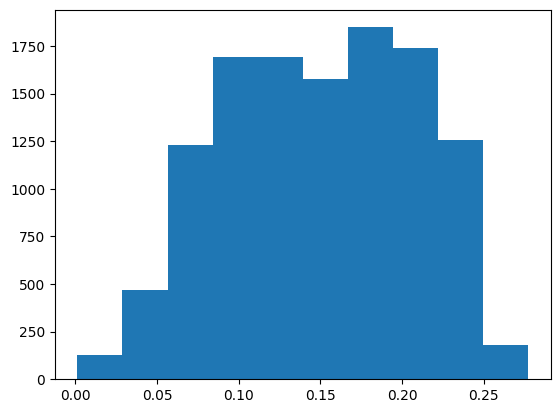

In [229]:
plt.hist(mu_vertex[mu_vertex > 0])